# Fine-tuning Qwen 3.5 0.8B
A notebook to fine-tune a model using Unsloth and save the resulting LoRA adapters.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["HF_HUB_OFFLINE"] = "1"

from dotenv import load_dotenv
load_dotenv()
SYSTEM_PROMPT = os.getenv("SYSTEM_PROMPT") 

import torch
from datasets import load_dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig

from evaluation import formatting_func

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


# Overfit Test
Ensure the model can actually learn from memorizing a small overfit dataset (`./data/overfit/train.jsonl`). The model should reach 100% accuracy.

Data format for `./data/echobot/` files:
```
id       → bookkeeping
query    → model input
label    → training target
source   → provenance
tag      → metadata / analysis
```

## Model + Data Prep

In [ ]:
# sys prompt + user query + assistant response < max_seq_length
max_seq_length = 2048

model, tokenizer= FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen3.5-0.8B",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
    full_finetuning = False,
    dtype = torch.bfloat16,
    device_map= "auto",
)

In [ ]:
train_path = "../data/overfit/train.jsonl"
val_path = "../data/echobot/val.jsonl"
test_path = "../data/overfit/train.jsonl"

dataset = load_dataset(
    "json",
    data_files={
        "train": train_path,
        "validation": val_path,
        "test": test_path,
    },
)
print(dataset['train'].features)

In [ ]:
from collections import Counter

# format dataset with only 'prompt' and 'completion' collumns
formatted_train = dataset["train"].map(
    formatting_func,
    remove_columns=dataset["train"].column_names
    )
formatted_val = dataset["validation"].map(
    formatting_func,
    remove_columns=dataset["validation"].column_names
    )
formatted_test = dataset["test"].map(
    formatting_func,
    remove_columns=dataset["test"].column_names
    )

print(Counter(formatted_train["completion"]))
print(Counter(formatted_val["completion"]))
print(Counter(formatted_test["completion"]))


```
Transformer block
│
├── Attention
│   ├── q_proj
│   ├── k_proj
│   ├── v_proj
│   └── o_proj
│
└── MLP
    ├── gate_proj
    ├── up_proj
    └── down_proj
```

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 8,
    lora_alpha = 8,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],

    finetune_vision_layers = False,
    finetune_language_layers = True, 
    finetune_attention_modules = True,
    finetune_mlp_modules = True,

    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",

    random_state = 8,
    max_seq_length = max_seq_length,
)

In [ ]:
model_name = "eb-ovrft-lora-qwen-v1"

trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_train,
    # eval_dataset=formatted_val,
    processing_class=tokenizer,

    args=SFTConfig(
        max_seq_length=max_seq_length,
        completion_only_loss=True,

        per_device_train_batch_size=8,
        gradient_accumulation_steps=4,
        warmup_steps=10,
        num_train_epochs=25,
        optim="adamw_8bit",

        seed=8,
        dataset_num_proc=1,

        output_dir=f"../checkpoints/{model_name}",
        logging_steps=1,
    ),
)

SFTTrainer loaded data information:
```
input_ids
    ↓
"What information does the model receive?"

attention_mask
    ↓
"Which positions are real tokens rather than padding?"

labels
    ↓
"Which next-token predictions should I grade,
 and what is the correct answer?"
```

In [ ]:
def inspect_sfttrainer_data(trainer):
    batch = next(iter(trainer.get_train_dataloader()))

    print(f"{batch.keys()=}")
    print()
    print(f"{batch['input_ids']=}")
    print()
    print(f"{batch['labels']=}")
    print()
    print(f"{batch['attention_mask']=}")
    print()
    print("-"*100)
    print()

    input_ids = batch["input_ids"][0]
    labels = batch["labels"][0]

    for token_id, label in zip(input_ids, labels):
        token = tokenizer.decode([token_id])
        print(f"{token!r:20} {label}")

## Training

In [ ]:
trainer.train()

## Evaluation

In [ ]:
from evaluation import (
    evaluate_model, 
    plot_loss
)

In [ ]:
plot_loss(trainer=trainer, show_val=False)

In [ ]:
evaluate_model(
    model=model, 
    tokenizer=tokenizer,
    dataset=dataset['test'],
    model_str=model_name,
    batch_size=16
)

## Save model adapters to disk

In [ ]:
adapter_path = f"../adapters/{model_name}"

model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

print(f"Saved LoRA adapter to {adapter_path}")

# Full Fine-Tuning Run
```
base:       Qwen 3.5 0.8B
quant:      4-bit NF4
compute:    BF16
LoRA rank:  16
LoRA dtype: BF16
```

## Model + Data Prep

In [2]:
max_seq_length = 2048
model_name = "eb-552-lora-qwen-v1"

model, tokenizer= FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen3.5-0.8B",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
    full_finetuning = False,
    dtype = torch.bfloat16,
    device_map= "auto",
)

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


==((====))==  Unsloth 2026.8.12: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100 80GB PCIe. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

In [3]:
train_path = "../data/echobot/train.jsonl"
val_path = "../data/echobot/val.jsonl"
test_path = "../data/echobot/test.jsonl"

dataset = load_dataset(
    "json",
    data_files={
        "train": train_path,
        "validation": val_path,
        "test": test_path,
    },
)
dataset["train"] = dataset["train"].shuffle(seed=8)
print(dataset['train'].features)

{'id': Value('string'), 'query': Value('string'), 'label': Value('int64'), 'source': Value('string'), 'tag': Value('string')}


In [4]:
from collections import Counter

# format dataset with only 'prompt' and 'completion' collumns
formatted_train = dataset["train"].map(
    formatting_func,
    remove_columns=dataset["train"].column_names
    )
formatted_val = dataset["validation"].map(
    formatting_func,
    remove_columns=dataset["validation"].column_names
    )
formatted_test = dataset["test"].map(
    formatting_func,
    remove_columns=dataset["test"].column_names
    )

print(Counter(formatted_train["completion"]))
print(Counter(formatted_val["completion"]))
print(Counter(formatted_test["completion"]))


Counter({'0': 278, '1': 274})
Counter({'0': 8, '1': 8})
Counter({'0': 42, '1': 36})


In [5]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 10,
    lora_alpha = 20,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        # "gate_proj", "up_proj", "down_proj",
    ],

    finetune_vision_layers = False,
    finetune_language_layers = True, 
    finetune_attention_modules = True,
    finetune_mlp_modules = True,

    lora_dropout = 0.10,
    bias = "none",
    use_gradient_checkpointing = "unsloth",

    random_state = 8,
    max_seq_length = max_seq_length,
)

Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.1.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


## Training

In [6]:
trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_train,
    eval_dataset=formatted_val,
    processing_class=tokenizer,

    args=SFTConfig(
        max_seq_length=max_seq_length,
        completion_only_loss=True,
        per_device_train_batch_size=8,

        eval_strategy="steps",
        gradient_accumulation_steps=4,
        warmup_ratio=0.05,
        num_train_epochs=3,
        optim="adamw_8bit",

        seed=8,
        dataset_num_proc=1,

        output_dir=f"../checkpoints/{model_name}",
        logging_steps=1,
    ),
)
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 552 | Num Epochs = 3 | Total steps = 54
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 675,840 of 853,661,760 (0.08% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
1,2.576193,2.632944
2,2.559113,2.624487
3,2.703043,2.546230
4,2.508001,2.396018
5,2.301215,2.180257
6,2.116041,1.928921
7,1.731558,1.712285
8,1.580122,1.425323
9,1.312829,1.219548
10,1.072977,0.993616


/home/mkpuzon/code/fine-tuning/.venv/lib/python3.13/site-packages/peft/utils/save_and_load.py:438: UserWarning: Could not find a config file in Qwen/Qwen3.5-0.8B - will assume that the vocabulary was not modified.
  warnings.warn(
Unsloth: Restored added_tokens_decoder metadata in ../checkpoints/eb-552-lora-qwen-v1/checkpoint-54/tokenizer_config.json.


TrainOutput(global_step=54, training_loss=0.6583941029729666, metrics={'train_runtime': 86.8218, 'train_samples_per_second': 19.074, 'train_steps_per_second': 0.622, 'total_flos': 734489799736320.0, 'train_loss': 0.6583941029729666, 'epoch': 3.0})

## Evaluation

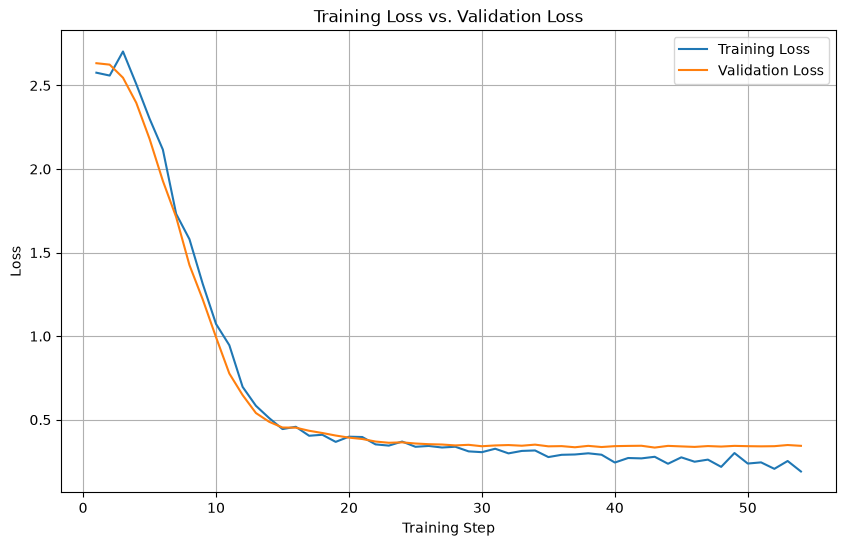

Accuracy: 44/78 = 0.5641
TPR (recall): 0.3889
FPR: 0.2857
Precision: 0.5385


In [7]:
from evaluation import (
    evaluate_model, 
    plot_loss
)
plot_loss(trainer=trainer, show_val=True)

evaluate_model(
    model=model, 
    tokenizer=tokenizer,
    dataset=dataset['test'],
    model_str=model_name,
    batch_size=16
)

## Save model adapters to disk 

In [9]:
adapter_path = f"../adapters/{model_name}"

model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

print(f"Saved LoRA adapter to {adapter_path}")

/home/mkpuzon/code/fine-tuning/.venv/lib/python3.13/site-packages/peft/utils/save_and_load.py:438: UserWarning: Could not find a config file in Qwen/Qwen3.5-0.8B - will assume that the vocabulary was not modified.
  warnings.warn(
Unsloth: Restored added_tokens_decoder metadata in ../adapters/eb-552-lora-qwen-v1/tokenizer_config.json.


Saved LoRA adapter to ../adapters/eb-552-lora-qwen-v1


# vLLM Notes

For serving model on vLLM
```bash
export VLLM_ALLOW_RUNTIME_LORA_UPDATING=True

vllm serve Qwen/Qwen3.5-0.8B \
    --enable-lora \
    --max-loras 4 \
    --max-lora-rank 64
```

To load an adapter inot the LoRA pool:
```bash
curl -X POST http://localhost:8000/v1/load_lora_adapter \
  -H "Content-Type: application/json" \
  -d '{
    "lora_name": "customer_support",
    "lora_path": "/absolute/path/to/lora_adapters/echobot_1"
  }'
```

To unload an adapter inot the LoRA pool:
```bash
curl -X POST http://localhost:8000/v1/unload_lora_adapter \
  -H "Content-Type: application/json" \
  -d '{
    "lora_name": "echobot_1"
  }'
```

To select model use:
```bash
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:8000/v1",
    api_key="EMPTY",
)

response = client.chat.completions.create(
    model="Qwen/Qwen3.5-0.8B",
    messages=[
        {
            "role": "user",
            "content": "Explain our refund policy."
        }
    ],
    extra_body={
        "lora_name": "customer_support"
    },
)

print(response.choices[0].message.content)
```